# Election Prediction Project
## Notebook 02 — Exploratory Data Analysis, Preprocessing and Feature Selection

### Notebook Objectives
This notebook ingests the unified dataset created in Notebook 01 and prepares it for the modeling phase.

**In this notebook, we perform the following steps:**
* **Quality Assurance:** Initial data overview and consistency checks.
* **Data Cleaning:** Converting input features into numeric format and handling missing values.
* **EDA:** Distribution analysis of target variables.
* **Data Splitting:** Chronological split (Election cycles prior to 2022 for Training; 2022 for Validation).
* **Feature Engineering:** Filtering and selection using Random Forest (performed on training data only).
* **Locality Classification:** Integrating settlement types and creating the `type_Druze_Majority` feature.
* **Export:** Saving a cleaned, pruned dataset for the modeling phase.

### Input

`processed_data/merged_elections_demographics.csv`

### Output

- `processed_data/modeling_dataset_selected_features.csv`
- `processed_data/selected_demographic_features.json`
- `reports/feature_importance_by_target.csv`
- `reports/training_missingness_summary.csv`
- `reports/preprocessing_summary.json`
- גרפי EDA בתיקייה `reports/figures/`


## 1. Imports and project configuration

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

RANDOM_STATE = 42
MISSINGNESS_THRESHOLD = 0.50
TOP_FEATURES_PER_TARGET = 10

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
from google.colab import drive

# Mount Google Drive
try:
    drive.mount("/content/drive")
except ValueError as error:
    if "already contain files" in str(error):
        print("Drive is already mounted. Continuing...")
    else:
        raise

# Central project paths
PROJECT_DIR = Path("/content/drive/MyDrive/לימודים/פרויקט DS")
PROCESSED_DIR = PROJECT_DIR / "processed_data"
REPORTS_DIR = PROJECT_DIR / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

INPUT_PATH = PROCESSED_DIR / "merged_elections_demographics.csv"
LOCALITY_TYPES_PATH = PROJECT_DIR / "Locality_Types.xlsx"

MODELING_OUTPUT_PATH = (
    PROCESSED_DIR / "modeling_dataset_selected_features.csv"
)
SELECTED_FEATURES_OUTPUT_PATH = (
    PROCESSED_DIR / "selected_demographic_features.json"
)
FEATURE_IMPORTANCE_OUTPUT_PATH = (
    REPORTS_DIR / "feature_importance_by_target.csv"
)
MISSINGNESS_OUTPUT_PATH = (
    REPORTS_DIR / "training_missingness_summary.csv"
)
PREPROCESSING_SUMMARY_OUTPUT_PATH = (
    REPORTS_DIR / "preprocessing_summary.json"
)

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input dataset: {INPUT_PATH}")
print(f"Locality types: {LOCALITY_TYPES_PATH}")
print(f"Processed-data directory: {PROCESSED_DIR}")
print(f"Reports directory: {REPORTS_DIR}")


Mounted at /content/drive
Input dataset: /content/drive/MyDrive/לימודים/פרויקט DS/processed_data/merged_elections_demographics.csv
Locality types: /content/drive/MyDrive/לימודים/פרויקט DS/Locality_Types.xlsx
Processed-data directory: /content/drive/MyDrive/לימודים/פרויקט DS/processed_data
Reports directory: /content/drive/MyDrive/לימודים/פרויקט DS/reports


## 2. Load and validate the merged dataset

In [3]:
if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"The input dataset was not found:\n{INPUT_PATH}\n"
        "Run Notebook 01 before continuing."
    )

df_raw = pd.read_csv(
    INPUT_PATH,
    low_memory=False
)

print(f"Dataset shape: {df_raw.shape}")
print(f"Unique localities: {df_raw['locality_symbol'].nunique()}")
print("Available columns:", len(df_raw.columns))

display(df_raw.head())


Dataset shape: (1124, 151)
Unique localities: 226
Available columns: 151


,locality_symbol,שם יישוב,year,target_election,"ילדים בגנים של משרד החינוך סה""כ",ילדים בגנים של משרד החינוך גיל 3,ילדים בגנים של משרד החינוך גיל 4,ילדים בגנים של משרד החינוך גיל 5,ילדים בגנים של משרד החינוך גיל 6,"בתי ספר סה""כ",בתי ספר יסודיים,בתי ספר על-יסודיים,בתי ספר חטיבות ביניים,בתי ספר תיכוניים,"כיתות סה""כ",כיתות בבתי ספר יסודיים,כיתות בבתי ספר על-יסודיים,כיתות בחטיבות ביניים,כיתות בבתי ספר תיכוניים,"תלמידים סה""כ",תלמידים בבתי ספר יסודיים,תלמידים בבתי ספר על-יסודיים,תלמידים בחטיבות ביניים,תלמידים בבתי ספר תיכוניים,ממוצע תלמידים לכיתה בבתי ספר יסודיים,"אחוז תלמידים נושרים סה""כ",אחוז תלמידים נושרים בנים,אחוז תלמידים נושרים בנות,אחוז זכאים לתעודת בגרות מבין תלמידי כיתות יב,אחוז זכאים לתעודת בגרות שעמדו בדרישות הסף של האוניברסיטאות מבין תלמידי כיתות יב,השכלה גבוהה אחוז בעלי תארים מישראל מתוך אוכלוסיית בני 55-35,השכלה גבוהה אחוז הנכנסים להשכלה גבוהה בתוך 8 שנים בקרב תלמידי יב,השכלה גבוהה אחוז סטודנטים מתוך אוכלוסיית בני 25-20,השכלה גבוהה אחוז סטודנטים מתוך כלל האוכלוסייה,עובדי הוראה מספר עובדי הוראה,עובדי הוראה ממוצע שעות עבודה לשבוע,עובדי הוראה אחוז עובדי הוראה חדשים,עובדי הוראה אחוז שעות היעדרות מסך שעות עבודה שנתיות,עובדי הוראה ממוצע שנות ותק מוכרות בהוראה,עובדי הוראה אחוז בעלי דרגת שכר תואר שני ומעלה,עובדי הוראה אחוז עובדי הוראה משתלמים מכלל עובדי הוראה,עובדי הוראה ממוצע תלמידים למורה,עובדי הוראה ממוצע שעות עבודה שבועיות לתלמיד,"צפיפות אוכלוסייה לקמ''ר ביישובים שמנו 5,000 תושבים ויותר","סה""כ אוכלוסייה בסוף השנה",סך כל הישראלים,יהודים ואחרים (אחוזים מתוך כלל אוכלוסיית הישראלים),יהודים (אחוזים מתוך יהודים ואחרים),ערבים (אחוזים מתוך כלל אוכלוסיית הישראלים),מוסלמים (אחוזים מתוך האוכלוסייה הערבית),נוצרים (אחוזים מתוך האוכלוסייה הערבית),דרוזים (אחוזים מתוך האוכלוסייה הערבית),"סה""כ גברים בסוף השנה","סה""כ נשים בסוף השנה",אחוז באוכלוסייה בסוף השנה בני 4-0,אחוז באוכלוסייה בסוף השנה בני 9-5,אחוז באוכלוסייה בסוף השנה בני 14-10,אחוז באוכלוסייה בסוף השנה בני 19-15,אחוז באוכלוסייה בסוף השנה בני 29-20,אחוז באוכלוסייה בסוף השנה בני 44-30,...,יוצאים ליישובים אחרים גברים,יוצאים ליישובים אחרים נשים,יוצאים ליישובים אחרים עד גיל 14,יוצאים ליישובים אחרים גיל 29-15,יוצאים ליישובים אחרים גיל 64-30,יוצאים ליישובים אחרים גיל 65 ומעלה,הגירה בתוך הרשות המקומית,"נישאים סה""כ גברים ונשים","נישאים שיעור ל-1,000 תושבים לא נשואים בני 15 ומעלה","מתגרשים סה""כ גברים ונשים","מתגרשים שיעור ל-1,000 תושבים נשואים בני 15 ומעלה",אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) סך מוסדות דיור משותף ברשות,אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) סך דיירי דיור משותף ברשות,אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים בבתי אבות ובדיור מוגן,אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים במוסדות חינוך,אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים במוסדות דת,אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים במוסדות אשפוז כולל הוסטלים,אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים במוסדות אחרים,avg_monthly_wage,"מספר מקבלי דמי אבטלה (סה""כ שנתי)",אחוז מקבלי דמי אבטלה מבני 67-20,"מקבלי דמי אבטלה (ממוצע חודשי) סה""כ",מקבלי דמי אבטלה (ממוצע חודשי) גברים,גיל ממוצע של מקבלי דמי אבטלה (לא כולל חיילים),"דמי אבטלה ממוצעים ליום (ש""ח)",ימי זכאות לדמי אבטלה (ממוצע שנתי),ניצול ימי אבטלה בשנה (ממוצע שנתי),ניצול ימי אבטלה בשנה (חציון שנתי),"מקבלי הכשרה מקצועית סה""כ","מקבלי קצבאות זקנה ושאירים סה""כ (סוף שנה)",אחוז מקבלי השלמת הכנסה מבין מקבלי קצבאות זקנה ושאירים,"מקבלי גמלת הבטחת הכנסה (נפשות, במשך השנה)",מקבלי גמלאות סיעוד (סוף שנה),מקבלי גמלאות נכות כללית (סוף שנה),מקבלי גמלאות ניידות (סוף שנה),מקבלי גמלאות נכות מעבודה ותלויים (סוף שנה),"אחוז המבוטחים בקופ""ח מתוך סך כל המבוטחים כללית","אחוז המבוטחים בקופ""ח מתוך סך כל המבוטחים מכבי","אחוז המבוטחים בקופ""ח מתוך סך כל המבוטחים מאוחדת","אחוז המבוטחים בקופ""ח מתוך סך כל המבוטחים לאומית","מספר משפחות של מקבלי קצבאות בגין ילדים (סוף שנה) סה""כ",מספר משפחות של מקבלי קצבאות בגין ילדים (סוף שנה) עם 2-1 ילדים במשפחה,מספר משפחות של מקבלי קצבאות בגין ילדים (סוף שנה) עם 4-3 ילדים במשפחה,מספר משפחות של מקבלי קצבאות בגין ילדים (סוף שנה) עם 5 ילדים ויותר במשפחה,

In [4]:
TARGET_COLUMNS = [
    "Right_pct",
    "Center_Left_pct",
    "Haredi_pct",
    "Arab_pct",
]

BASE_METADATA_COLUMNS = [
    "locality_symbol",
    "שם יישוב",
    "year",
    "target_election",
]

AUDIT_COLUMNS = [
    "valid_votes",
    "Other_raw_pct",
]

# These election-derived columns must never be used as model features.
LEAKAGE_COLUMNS = [
    "Right",
    "Center_Left",
    "Haredi",
    "Arab",
    "Other",
    "total_main_blocks",
    "valid_votes",
    "Other_raw_pct",
]

required_columns = [
    "locality_symbol",
    "year",
    "target_election",
    *TARGET_COLUMNS,
]

missing_required_columns = [
    column
    for column in required_columns
    if column not in df_raw.columns
]

if missing_required_columns:
    raise ValueError(
        f"Missing required columns: {missing_required_columns}"
    )

# Normalize key columns
df_raw["locality_symbol"] = (
    pd.to_numeric(
        df_raw["locality_symbol"],
        errors="coerce"
    )
    .astype("Int64")
    .astype("string")
)

df_raw["year"] = pd.to_numeric(
    df_raw["year"],
    errors="coerce"
)

# Quality checks inherited from Notebook 01
if df_raw[["locality_symbol", "year", "target_election"]].isna().any().any():
    raise ValueError(
        "Missing values were found in key identifier columns."
    )

if df_raw[TARGET_COLUMNS].isna().any().any():
    raise ValueError(
        "Missing values were found in target columns."
    )

target_sums = df_raw[TARGET_COLUMNS].sum(axis=1)

if not np.allclose(target_sums, 100, atol=1e-6):
    raise ValueError(
        "At least one row does not sum to 100% across the targets."
    )

duplicate_count = df_raw.duplicated(
    subset=["locality_symbol", "target_election"]
).sum()

if duplicate_count > 0:
    raise ValueError(
        f"Found {duplicate_count} duplicate locality-election rows."
    )

print("Initial quality checks passed.")
print(f"Minimum target sum: {target_sums.min():.6f}")
print(f"Maximum target sum: {target_sums.max():.6f}")


Initial quality checks passed.
Minimum target sum: 100.000000
Maximum target sum: 100.000000


,target_election,year,rows,unique_localities
0,Knesset_21,2019,225,225
1,Knesset_22,2019,225,225
2,Knesset_23,2020,224,224
3,Knesset_24,2021,224,224
4,Knesset_25,2022,226,226


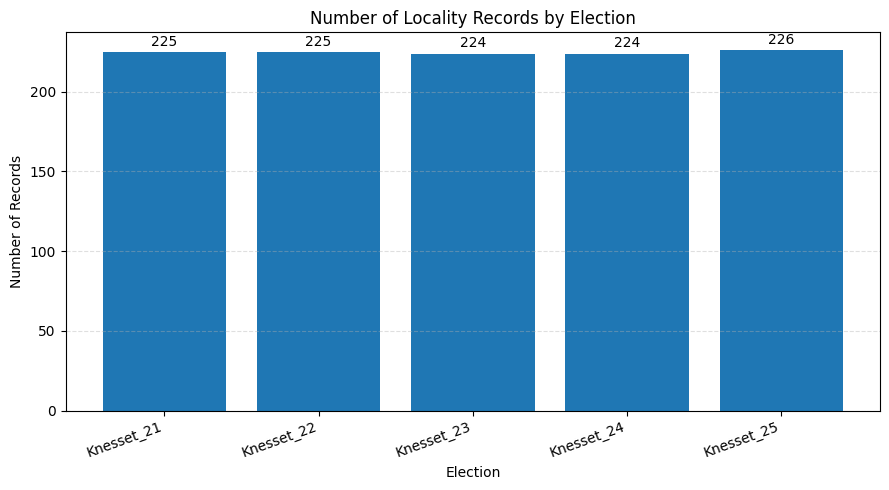

In [5]:
election_overview = (
    df_raw
    .groupby(
        ["target_election", "year"],
        as_index=False
    )
    .agg(
        rows=("locality_symbol", "size"),
        unique_localities=("locality_symbol", "nunique")
    )
    .sort_values(["year", "target_election"])
)

display(election_overview)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    election_overview["target_election"],
    election_overview["rows"]
)

plt.title("Number of Locality Records by Election")
plt.xlabel("Election")
plt.ylabel("Number of Records")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar, value in zip(bars, election_overview["rows"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{int(value)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "records_by_election.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


## 3. Define candidate demographic features



In [6]:
excluded_columns = set(
    BASE_METADATA_COLUMNS
    + TARGET_COLUMNS
    + LEAKAGE_COLUMNS
)

candidate_feature_columns = [
    column
    for column in df_raw.columns
    if column not in excluded_columns
    and not column.startswith("type_")
]

print(
    "Initial candidate demographic features:",
    len(candidate_feature_columns)
)

print("\nExamples:")
for column in candidate_feature_columns[:15]:
    print(f"- {column}")


Initial candidate demographic features: 135

Examples:
- ילדים בגנים של משרד החינוך סה"כ
- ילדים בגנים של משרד החינוך גיל 3
- ילדים בגנים של משרד החינוך גיל 4
- ילדים בגנים של משרד החינוך גיל 5
- ילדים בגנים של משרד החינוך גיל 6
- בתי ספר סה"כ
- בתי ספר יסודיים
- בתי ספר על-יסודיים
- בתי ספר חטיבות ביניים
- בתי ספר תיכוניים
- כיתות סה"כ
- כיתות בבתי ספר יסודיים
- כיתות בבתי ספר על-יסודיים
- כיתות בחטיבות ביניים
- כיתות בבתי ספר תיכוניים


In [7]:
MISSING_TOKENS = {
    "": np.nan,
    "nan": np.nan,
    "NaN": np.nan,
    "None": np.nan,
    "..": np.nan,
    "...": np.nan,
    "-": np.nan,
    "—": np.nan,
    "–": np.nan,
}


def convert_series_to_numeric(series):
    """Convert a feature series to numeric while preserving missing data."""
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")

    cleaned = (
        series
        .astype("string")
        .str.strip()
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .replace(MISSING_TOKENS)
    )

    return pd.to_numeric(
        cleaned,
        errors="coerce"
    )


df_clean = df_raw.copy()

for column in candidate_feature_columns:
    df_clean[column] = convert_series_to_numeric(
        df_clean[column]
    )

for column in TARGET_COLUMNS:
    df_clean[column] = pd.to_numeric(
        df_clean[column],
        errors="coerce"
    )

df_clean = df_clean.replace(
    [np.inf, -np.inf],
    np.nan
)

print("Feature conversion completed.")
print(
    "Numeric candidate features:",
    df_clean[candidate_feature_columns]
    .select_dtypes(include=np.number)
    .shape[1]
)
print(
    "Total missing candidate-feature cells:",
    int(
        df_clean[candidate_feature_columns]
        .isna()
        .sum()
        .sum()
    )
)


Feature conversion completed.
Numeric candidate features: 135
Total missing candidate-feature cells: 30705


## 4. Exploratory Data Analysis

In [8]:
target_summary = (
    df_clean[TARGET_COLUMNS]
    .describe()
    .T
    .rename_axis("Target")
)

display(target_summary.round(3))

mean_by_election = (
    df_clean
    .groupby(
        ["target_election", "year"]
    )[TARGET_COLUMNS]
    .mean()
    .round(3)
)

print("Mean target percentages by election:")
display(mean_by_election)


,count,mean,std,min,25%,50%,75%,max
Target,,,,,,,,
Right_pct,1124.0,34.991,26.859,0.079,5.481,35.684,57.005,96.802
Center_Left_pct,1124.0,29.417,25.476,0.072,6.541,22.192,48.966,97.706
Haredi_pct,1124.0,9.470,17.287,0.000,0.697,3.533,10.252,98.820
Arab_pct,1124.0,26.122,39.308,0.000,0.087,0.458,68.732,99.380


Mean target percentages by election:


,,Right_pct,Center_Left_pct,Haredi_pct,Arab_pct
target_election,year,,,,
Knesset_21,2019,36.483,32.527,8.551,22.438
Knesset_22,2019,32.314,31.657,10.168,25.861
Knesset_23,2020,33.508,28.200,9.818,28.473
Knesset_24,2021,39.128,25.658,9.166,26.049
Knesset_25,2022,33.537,29.023,9.647,27.793


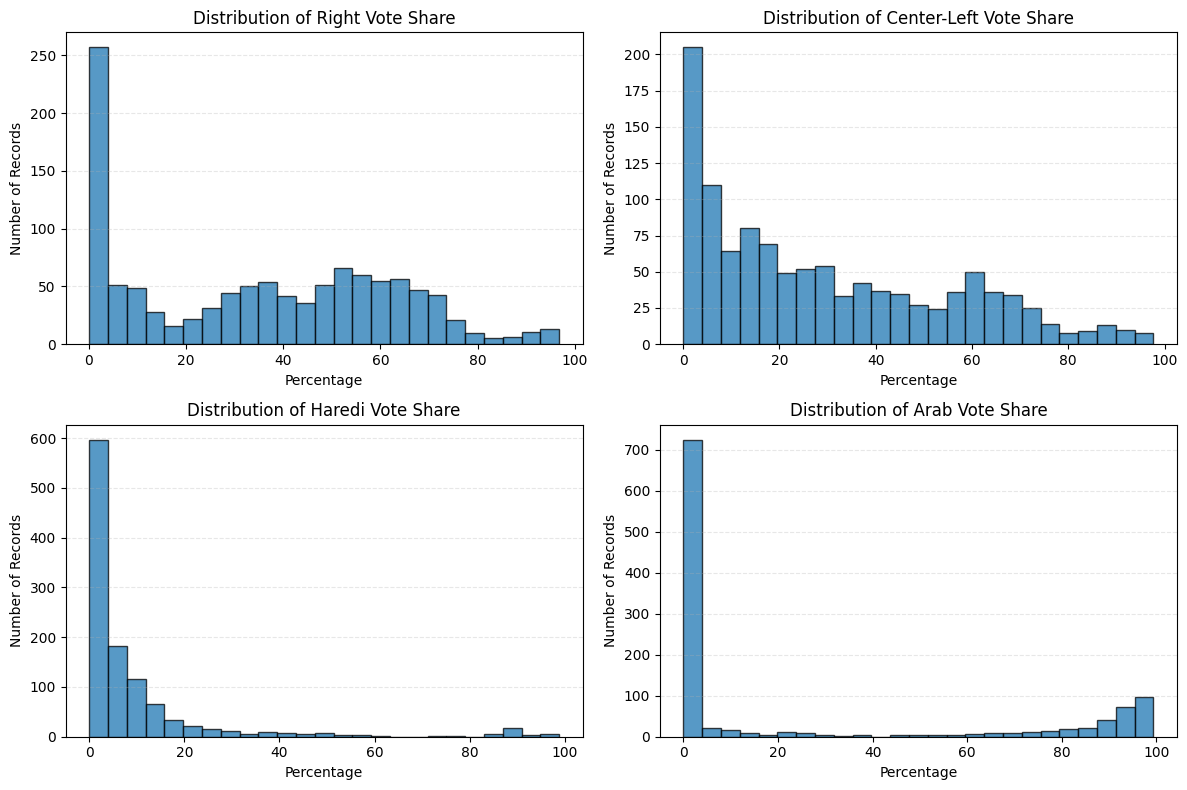

In [9]:
target_titles = {
    "Right_pct": "Right",
    "Center_Left_pct": "Center-Left",
    "Haredi_pct": "Haredi",
    "Arab_pct": "Arab",
}

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8)
)

for axis, target in zip(
    axes.flatten(),
    TARGET_COLUMNS
):
    axis.hist(
        df_clean[target].dropna(),
        bins=25,
        edgecolor="black",
        alpha=0.75
    )

    axis.set_title(
        f"Distribution of {target_titles[target]} Vote Share"
    )
    axis.set_xlabel("Percentage")
    axis.set_ylabel("Number of Records")
    axis.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "target_distributions.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


,Right_pct,Center_Left_pct,Haredi_pct,Arab_pct
Right_pct,1.000,0.034,0.094,-0.747
Center_Left_pct,0.034,1.000,-0.293,-0.542
Haredi_pct,0.094,-0.293,1.000,-0.314
Arab_pct,-0.747,-0.542,-0.314,1.000


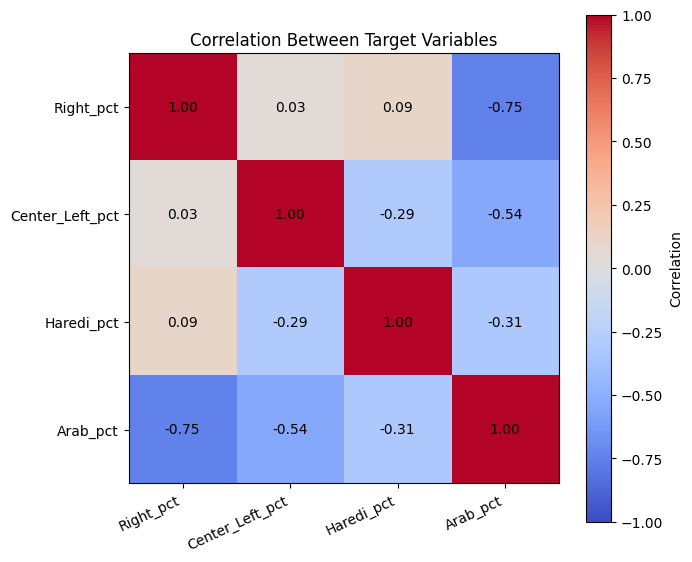

In [10]:
target_correlation = (
    df_clean[TARGET_COLUMNS]
    .corr()
)

display(target_correlation.round(3))

plt.figure(figsize=(7, 6))

image = plt.imshow(
    target_correlation,
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

plt.colorbar(
    image,
    label="Correlation"
)

plt.xticks(
    range(len(TARGET_COLUMNS)),
    TARGET_COLUMNS,
    rotation=25,
    ha="right"
)

plt.yticks(
    range(len(TARGET_COLUMNS)),
    TARGET_COLUMNS
)

for row_index in range(len(TARGET_COLUMNS)):
    for column_index in range(len(TARGET_COLUMNS)):
        plt.text(
            column_index,
            row_index,
            f"{target_correlation.iloc[row_index, column_index]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Between Target Variables")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "target_correlation.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


Features with missing values: 135


,Missing_Rate,Missing_Count
"מקבלי הכשרה מקצועית סה""כ",96.7%,"1,087"
אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים במוסדות חינוך,89.9%,"1,010"
"שיעור פטירות תינוקות ל-1,000 לידות חי",89.2%,"1,003"
אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים במוסדות דת,89.0%,"1,000"
אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים בבתי אבות ובדיור מוגן,88.8%,998
אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים במוסדות אחרים,88.1%,990
אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) אחוז דיירים במוסדות אשפוז כולל הוסטלים,87.4%,982
אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) סך מוסדות דיור משותף ברשות,82.6%,928
אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשות) סך דיירי דיור משותף ברשות,82.6%,928
דרוזים (אחוזים מתוך האוכלוסייה הערבית),76.3%,858


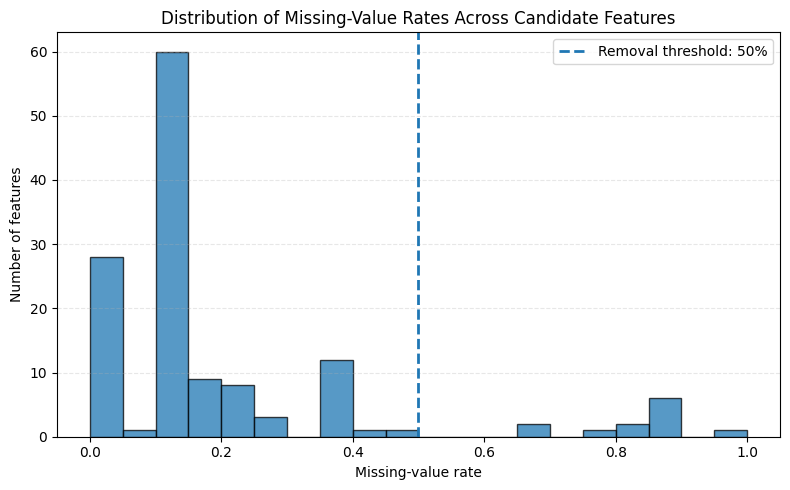

In [11]:
overall_missingness = (
    df_clean[candidate_feature_columns]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("Missing_Rate")
    .to_frame()
)

overall_missingness["Missing_Count"] = (
    df_clean[candidate_feature_columns]
    .isna()
    .sum()
)

print(
    "Features with missing values:",
    int((overall_missingness["Missing_Rate"] > 0).sum())
)

display(
    overall_missingness
    .head(20)
    .style
    .format({
        "Missing_Rate": "{:.1%}",
        "Missing_Count": "{:,.0f}",
    })
)

plt.figure(figsize=(8, 5))

plt.hist(
    overall_missingness["Missing_Rate"],
    bins=np.linspace(0, 1, 21),
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    MISSINGNESS_THRESHOLD,
    linestyle="--",
    linewidth=2,
    label=f"Removal threshold: {MISSINGNESS_THRESHOLD:.0%}"
)

plt.title("Distribution of Missing-Value Rates Across Candidate Features")
plt.xlabel("Missing-value rate")
plt.ylabel("Number of features")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "feature_missingness_distribution.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


## 5. Chronological train-validation split

The 2022 elections act as a retrospective validation set. In the presence of the target_election column, the split is based on Knesset_25, maintaining the separation between the two 2019 election cycles


In [12]:
VALIDATION_ELECTION = "Knesset_25"

if "target_election" in df_clean.columns:
    validation_mask = (
        df_clean["target_election"]
        .eq(VALIDATION_ELECTION)
    )
else:
    validation_mask = (
        df_clean["year"]
        .eq(2022)
    )

train_df = df_clean.loc[
    ~validation_mask
].copy()

validation_df = df_clean.loc[
    validation_mask
].copy()

if train_df.empty:
    raise ValueError(
        "The training dataset is empty."
    )

if validation_df.empty:
    raise ValueError(
        "The validation dataset is empty."
    )

print("Chronological split completed.")
print(f"Training rows: {len(train_df)}")
print(f"Validation rows: {len(validation_df)}")

print("\nTraining elections:")
print(
    train_df["target_election"]
    .value_counts()
    .sort_index()
)

print("\nValidation elections:")
print(
    validation_df["target_election"]
    .value_counts()
    .sort_index()
)


Chronological split completed.
Training rows: 898
Validation rows: 226

Training elections:
target_election
Knesset_21    225
Knesset_22    225
Knesset_23    224
Knesset_24    224
Name: count, dtype: int64

Validation elections:
target_election
Knesset_25    226
Name: count, dtype: int64


## 6. Remove unusable features using training data only

**Filtering is based solely on the training set, applying the following criteria:**
* Columns with more than 50% missing values.
* Columns where all values are missing.
* Constant columns with zero variance.

*To prevent data leakage, the validation set is excluded from these decisions.


In [13]:
training_missingness = (
    train_df[candidate_feature_columns]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("Training_Missing_Rate")
    .to_frame()
)

training_missingness["Training_Missing_Count"] = (
    train_df[candidate_feature_columns]
    .isna()
    .sum()
)

training_missingness["Validation_Missing_Rate"] = (
    validation_df[candidate_feature_columns]
    .isna()
    .mean()
)

training_missingness["Validation_Missing_Count"] = (
    validation_df[candidate_feature_columns]
    .isna()
    .sum()
)

high_missingness_features = (
    training_missingness
    .index[
        training_missingness["Training_Missing_Rate"]
        > MISSINGNESS_THRESHOLD
    ]
    .tolist()
)

all_missing_training_features = [
    column
    for column in candidate_feature_columns
    if train_df[column].isna().all()
]

constant_training_features = [
    column
    for column in candidate_feature_columns
    if train_df[column].nunique(dropna=True) <= 1
]

removed_features = list(
    dict.fromkeys(
        high_missingness_features
        + all_missing_training_features
        + constant_training_features
    )
)

usable_candidate_features = [
    column
    for column in candidate_feature_columns
    if column not in removed_features
]

training_missingness["Removed_From_Feature_Selection"] = (
    training_missingness.index.isin(
        removed_features
    )
)

training_missingness.to_csv(
    MISSINGNESS_OUTPUT_PATH,
    encoding="utf-8-sig"
)

print(
    "Candidate features before filtering:",
    len(candidate_feature_columns)
)
print(
    "Features removed:",
    len(removed_features)
)
print(
    "Usable candidate features:",
    len(usable_candidate_features)
)

print("\nRemoval reasons:")
print(
    f"- Above {MISSINGNESS_THRESHOLD:.0%} missing in training: "
    f"{len(high_missingness_features)}"
)
print(
    f"- Completely missing in training: "
    f"{len(all_missing_training_features)}"
)
print(
    f"- Constant in training: "
    f"{len(constant_training_features)}"
)

if removed_features:
    removed_feature_table = pd.DataFrame({
        "Feature": removed_features,
        "High_Missingness": [
            feature in high_missingness_features
            for feature in removed_features
        ],
        "All_Missing": [
            feature in all_missing_training_features
            for feature in removed_features
        ],
        "Constant": [
            feature in constant_training_features
            for feature in removed_features
        ],
    })

    display(removed_feature_table)


Candidate features before filtering: 135
Features removed: 12
Usable candidate features: 123

Removal reasons:
- Above 50% missing in training: 12
- Completely missing in training: 0
- Constant in training: 0


,Feature,High_Missingness,All_Missing,Constant
0,"מקבלי הכשרה מקצועית סה""כ",True,False,False
1,"שיעור פטירות תינוקות ל-1,000 לידות חי",True,False,False
2,אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשו...,True,False,False
3,אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשו...,True,False,False
4,אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשו...,True,False,False
5,אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשו...,True,False,False
6,אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשו...,True,False,False
7,אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשו...,True,False,False
8,אוכלוסיית דיור משותף (אחוז מתוך אוכלוסיית הרשו...,True,False,False
9,דרוזים (אחוזים מתוך האוכלוסייה הערבית),True,False,False


## 7. Training-only feature selection




In [14]:
def select_features_by_target(
    training_data,
    feature_columns,
    target_columns,
    top_n=10,
    random_state=42
):
    """Select top features for each target using training data only."""

    X_train_raw = (
        training_data[feature_columns]
        .copy()
    )

    imputer = SimpleImputer(
        strategy="median"
    )

    X_train_imputed = pd.DataFrame(
        imputer.fit_transform(X_train_raw),
        columns=feature_columns,
        index=X_train_raw.index
    )

    selected_features = []
    importance_frames = []

    for target in target_columns:
        y_train = pd.to_numeric(
            training_data[target],
            errors="coerce"
        )

        valid_rows = y_train.notna()

        if valid_rows.sum() == 0:
            raise ValueError(
                f"No valid training values were found for {target}."
            )

        model = RandomForestRegressor(
            n_estimators=300,
            random_state=random_state,
            n_jobs=-1
        )

        model.fit(
            X_train_imputed.loc[valid_rows],
            y_train.loc[valid_rows]
        )

        target_importance = pd.DataFrame({
            "Target": target,
            "Feature": feature_columns,
            "Importance": model.feature_importances_,
        })

        target_importance = (
            target_importance
            .sort_values(
                "Importance",
                ascending=False
            )
            .reset_index(drop=True)
        )

        target_importance["Rank"] = (
            np.arange(
                1,
                len(target_importance) + 1
            )
        )

        target_importance["Selected_Top_N"] = (
            target_importance["Rank"]
            .le(top_n)
        )

        importance_frames.append(
            target_importance
        )

        top_features = (
            target_importance
            .head(top_n)["Feature"]
            .tolist()
        )

        for feature in top_features:
            if feature not in selected_features:
                selected_features.append(feature)

    importance_table = pd.concat(
        importance_frames,
        ignore_index=True
    )

    return (
        selected_features,
        importance_table,
        imputer
    )


In [15]:
(
    selected_demographic_features,
    feature_importance_table,
    feature_selection_imputer,
) = select_features_by_target(
    training_data=train_df,
    feature_columns=usable_candidate_features,
    target_columns=TARGET_COLUMNS,
    top_n=TOP_FEATURES_PER_TARGET,
    random_state=RANDOM_STATE
)

print(
    "Selected demographic features:",
    len(selected_demographic_features)
)

for index, feature in enumerate(
    selected_demographic_features,
    start=1
):
    print(f"{index:>2}. {feature}")

print("\nTop features by target:")

for target in TARGET_COLUMNS:
    print(f"\n{target}")

    display(
        feature_importance_table.loc[
            (
                feature_importance_table["Target"]
                == target
            )
            & (
                feature_importance_table[
                    "Selected_Top_N"
                ]
            ),
            [
                "Rank",
                "Feature",
                "Importance",
            ],
        ]
        .round({
            "Importance": 4
        })
        .reset_index(drop=True)
    )


Selected demographic features: 25
 1. אחוז עולי + מסך האוכלוסייה
 2. אחוז מקבלי השלמת הכנסה מבין מקבלי קצבאות זקנה ושאירים
 3. אחוז זכאים לתעודת בגרות מבין תלמידי כיתות יב
 4. עובדי הוראה ממוצע שעות עבודה שבועיות לתלמיד
 5. מספר ילדים שבגינם שולמו קצבאות במשפחות עם 5 ילדים ויותר
 6. השכלה גבוהה אחוז בעלי תארים מישראל מתוך אוכלוסיית בני 55-35
 7. מקבלי קצבאות זקנה ושאירים סה"כ (סוף שנה)
 8. אחוז המבוטחים בקופ"ח מתוך סך כל המבוטחים כללית
 9. avg_monthly_wage
10. עובדי הוראה ממוצע תלמידים למורה
11. אחוז באוכלוסייה בסוף השנה בני 4-0
12. אחוז זכאים לתעודת בגרות שעמדו בדרישות הסף של האוניברסיטאות מבין תלמידי כיתות יב
13. ריבוי טבעי ל-1,000 תושבים
14. אחוז באוכלוסייה בסוף השנה בני 44-30
15. גיל ממוצע של מקבלי דמי אבטלה (לא כולל חיילים)
16. עובדי הוראה אחוז בעלי דרגת שכר תואר שני ומעלה
17. שיעור פריון כולל
18. יחס תלות (ל-1,000 תושבים בלתי תלויים)
19. מקבלי גמלת הבטחת הכנסה (נפשות, במשך השנה)
20. עובדי הוראה ממוצע שעות עבודה לשבוע
21. אחוז באוכלוסייה בסוף השנה בני 9-5
22. מוסלמים (אחוזים מתוך 

,Rank,Feature,Importance
0,1,אחוז עולי + מסך האוכלוסייה,0.5249
1,2,אחוז מקבלי השלמת הכנסה מבין מקבלי קצבאות זקנה ...,0.0592
2,3,אחוז זכאים לתעודת בגרות מבין תלמידי כיתות יב,0.0485
3,4,עובדי הוראה ממוצע שעות עבודה שבועיות לתלמיד,0.0241
4,5,מספר ילדים שבגינם שולמו קצבאות במשפחות עם 5 יל...,0.0180
5,6,השכלה גבוהה אחוז בעלי תארים מישראל מתוך אוכלוס...,0.0166
6,7,"מקבלי קצבאות זקנה ושאירים סה""כ (סוף שנה)",0.0163
7,8,"אחוז המבוטחים בקופ""ח מתוך סך כל המבוטחים כללית",0.0139
8,9,avg_monthly_wage,0.0136
9,10,עובדי הוראה ממוצע תלמידים למורה,0.0122



Center_Left_pct


,Rank,Feature,Importance
0,1,אחוז באוכלוסייה בסוף השנה בני 4-0,0.1863
1,2,אחוז מקבלי השלמת הכנסה מבין מקבלי קצבאות זקנה ...,0.1074
2,3,אחוז זכאים לתעודת בגרות שעמדו בדרישות הסף של ה...,0.0913
3,4,השכלה גבוהה אחוז בעלי תארים מישראל מתוך אוכלוס...,0.0714
4,5,"ריבוי טבעי ל-1,000 תושבים",0.0598
5,6,אחוז באוכלוסייה בסוף השנה בני 44-30,0.0488
6,7,avg_monthly_wage,0.0412
7,8,"אחוז המבוטחים בקופ""ח מתוך סך כל המבוטחים כללית",0.0268
8,9,גיל ממוצע של מקבלי דמי אבטלה (לא כולל חיילים),0.0186
9,10,"מקבלי קצבאות זקנה ושאירים סה""כ (סוף שנה)",0.0180



Haredi_pct


,Rank,Feature,Importance
0,1,אחוז זכאים לתעודת בגרות שעמדו בדרישות הסף של ה...,0.3231
1,2,אחוז זכאים לתעודת בגרות מבין תלמידי כיתות יב,0.1714
2,3,עובדי הוראה אחוז בעלי דרגת שכר תואר שני ומעלה,0.1317
3,4,שיעור פריון כולל,0.0338
4,5,"יחס תלות (ל-1,000 תושבים בלתי תלויים)",0.0258
5,6,"מקבלי גמלת הבטחת הכנסה (נפשות, במשך השנה)",0.0186
6,7,אחוז עולי + מסך האוכלוסייה,0.0184
7,8,עובדי הוראה ממוצע שעות עבודה לשבוע,0.0158
8,9,אחוז באוכלוסייה בסוף השנה בני 9-5,0.0135
9,10,מספר ילדים שבגינם שולמו קצבאות במשפחות עם 5 יל...,0.0112



Arab_pct


,Rank,Feature,Importance
0,1,אחוז עולי + מסך האוכלוסייה,0.7173
1,2,מספר ילדים שבגינם שולמו קצבאות במשפחות עם 5 יל...,0.0740
2,3,אחוז באוכלוסייה בסוף השנה בני 44-30,0.0719
3,4,מוסלמים (אחוזים מתוך האוכלוסייה הערבית),0.0208
4,5,ערבים (אחוזים מתוך כלל אוכלוסיית הישראלים),0.0128
5,6,יהודים ואחרים (אחוזים מתוך כלל אוכלוסיית הישרא...,0.0092
6,7,אחוז זכאים לתעודת בגרות מבין תלמידי כיתות יב,0.0076
7,8,"מקבלי גמלת הבטחת הכנסה (נפשות, במשך השנה)",0.0045
8,9,ממוצע תלמידים לכיתה בבתי ספר יסודיים,0.0032
9,10,"אחוז המבוטחים בקופ""ח מתוך סך כל המבוטחים כללית",0.0030


In [16]:
feature_importance_table.to_csv(
    FEATURE_IMPORTANCE_OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig"
)

selected_feature_payload = {
    "selection_method": (
        "RandomForestRegressor feature importance "
        "on training elections only"
    ),
    "validation_election": VALIDATION_ELECTION,
    "top_features_per_target": TOP_FEATURES_PER_TARGET,
    "missingness_threshold": MISSINGNESS_THRESHOLD,
    "selected_feature_count": len(
        selected_demographic_features
    ),
    "selected_demographic_features": (
        selected_demographic_features
    ),
}

with open(
    SELECTED_FEATURES_OUTPUT_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        selected_feature_payload,
        file,
        ensure_ascii=False,
        indent=2
    )

print("Feature-selection artifacts saved:")
print(f"- {FEATURE_IMPORTANCE_OUTPUT_PATH}")
print(f"- {SELECTED_FEATURES_OUTPUT_PATH}")


Feature-selection artifacts saved:
- /content/drive/MyDrive/לימודים/פרויקט DS/reports/feature_importance_by_target.csv
- /content/drive/MyDrive/לימודים/פרויקט DS/processed_data/selected_demographic_features.json


## 8. Add locality-type classifications


In [17]:
if not LOCALITY_TYPES_PATH.exists():
    raise FileNotFoundError(
        f"The locality-type file was not found:\n"
        f"{LOCALITY_TYPES_PATH}"
    )

locality_types_raw = pd.read_excel(
    LOCALITY_TYPES_PATH
)

print(
    "Locality-type dataset shape:",
    locality_types_raw.shape
)

print("Columns:")
print(locality_types_raw.columns.tolist())

display(locality_types_raw.head())


Locality-type dataset shape: (1270, 5)
Columns:
['שם יישוב', 'סמל יישוב', 'צורת יישוב', 'type', 'סוג יישוב']


,שם יישוב,סמל יישוב,צורת יישוב,type,סוג יישוב
0,JERUSALEM,3000,120,Cities,"יישובים יהודיים 500,000 תושבים ומעלה"
1,ASHDOD,70,130,Cities,"יישובים יהודיים 499,999-200,000 תושבים"
2,BE'ER SHEVA,9000,130,Cities,"יישובים יהודיים 499,999-200,000 תושבים"
3,BENE BERAQ,6100,130,Cities,"יישובים יהודיים 499,999-200,000 תושבים"
4,HAIFA,4000,130,Cities,"יישובים יהודיים 499,999-200,000 תושבים"


In [18]:
def find_first_existing_column(
    dataframe,
    candidates
):
    """Return the first matching column name."""
    return next(
        (
            column
            for column in candidates
            if column in dataframe.columns
        ),
        None
    )


classification_id_column = find_first_existing_column(
    locality_types_raw,
    [
        "סמל יישוב",
        "סמל ישוב",
        "locality_symbol",
    ]
)

classification_type_column = find_first_existing_column(
    locality_types_raw,
    [
        "type",
        "TYPE",
        "סוג יישוב",
        "סוג ישוב",
    ]
)

if classification_id_column is None:
    raise ValueError(
        "A locality identifier column was not found "
        "in Locality_Types.xlsx."
    )

if classification_type_column is None:
    raise ValueError(
        "A locality-type column was not found "
        "in Locality_Types.xlsx."
    )

print(
    "Classification ID column:",
    classification_id_column
)
print(
    "Classification type column:",
    classification_type_column
)

locality_types = locality_types_raw[
    [
        classification_id_column,
        classification_type_column,
    ]
].copy()

locality_types["locality_symbol"] = (
    pd.to_numeric(
        locality_types[
            classification_id_column
        ],
        errors="coerce"
    )
    .astype("Int64")
    .astype("string")
)

locality_types["locality_type"] = (
    locality_types[
        classification_type_column
    ]
    .astype("string")
    .str.strip()
)

locality_types = locality_types.dropna(
    subset=[
        "locality_symbol",
        "locality_type",
    ]
)

conflicting_classifications = (
    locality_types
    .groupby("locality_symbol")[
        "locality_type"
    ]
    .nunique()
)

conflicting_classifications = (
    conflicting_classifications[
        conflicting_classifications > 1
    ]
)

if not conflicting_classifications.empty:
    raise ValueError(
        "Conflicting locality classifications were found "
        f"for {len(conflicting_classifications)} localities."
    )

locality_types = (
    locality_types[
        [
            "locality_symbol",
            "locality_type",
        ]
    ]
    .drop_duplicates(
        subset="locality_symbol"
    )
)

print(
    "Unique classified localities:",
    locality_types[
        "locality_symbol"
    ].nunique()
)

print("\nOriginal type distribution:")
print(
    locality_types[
        "locality_type"
    ]
    .value_counts(
        dropna=False
    )
)


Classification ID column: סמל יישוב
Classification type column: type
Unique classified localities: 1270

Original type distribution:
locality_type
Moshavim           453
other              274
Kibbutzim          268
Cities             174
Arab/Non-Jewish    101
Name: count, dtype: Int64


In [19]:
EXPECTED_TYPE_VALUES = {
    "Arab/Non-Jewish",
    "Cities",
    "Kibbutzim",
    "Moshavim",
    "other",
}

TYPE_VALUE_ALIASES = {
    "City": "Cities",
    "city": "Cities",
    "Kibbutz": "Kibbutzim",
    "kibbutz": "Kibbutzim",
    "Moshav": "Moshavim",
    "moshav": "Moshavim",
    "Other": "other",
    "OTHER": "other",
}

locality_types["locality_type"] = (
    locality_types["locality_type"]
    .replace(TYPE_VALUE_ALIASES)
)

unexpected_types = sorted(
    set(
        locality_types["locality_type"]
        .dropna()
        .unique()
    )
    - EXPECTED_TYPE_VALUES
)

if unexpected_types:
    print(
        "Unexpected locality types will be assigned to 'other':"
    )

    for value in unexpected_types:
        print(f"- {value}")

    locality_types.loc[
        locality_types[
            "locality_type"
        ].isin(unexpected_types),
        "locality_type"
    ] = "other"

df_with_types = pd.merge(
    df_clean,
    locality_types,
    on="locality_symbol",
    how="left",
    validate="many_to_one"
)

missing_type_rows = (
    df_with_types[
        "locality_type"
    ]
    .isna()
    .sum()
)

missing_type_localities = (
    df_with_types.loc[
        df_with_types[
            "locality_type"
        ].isna(),
        "locality_symbol"
    ]
    .nunique()
)

print(
    "Rows without a matched classification:",
    missing_type_rows
)
print(
    "Unique localities without a matched classification:",
    missing_type_localities
)

df_with_types["locality_type"] = (
    df_with_types[
        "locality_type"
    ]
    .fillna("other")
)

classification_dummies = pd.get_dummies(
    df_with_types["locality_type"],
    prefix="type",
    dtype=int
)

EXPECTED_CLASSIFICATION_FEATURES = [
    "type_Arab/Non-Jewish",
    "type_Cities",
    "type_Kibbutzim",
    "type_Moshavim",
    "type_other",
]

for column in EXPECTED_CLASSIFICATION_FEATURES:
    if column not in classification_dummies.columns:
        classification_dummies[column] = 0

unexpected_dummy_columns = [
    column
    for column in classification_dummies.columns
    if column not in EXPECTED_CLASSIFICATION_FEATURES
]

if unexpected_dummy_columns:
    raise ValueError(
        "Unexpected classification dummy columns were created: "
        f"{unexpected_dummy_columns}"
    )

classification_dummies = classification_dummies[
    EXPECTED_CLASSIFICATION_FEATURES
]

df_with_types = pd.concat(
    [
        df_with_types.drop(
            columns=["locality_type"]
        ),
        classification_dummies,
    ],
    axis=1
)

dummy_sums = (
    df_with_types[
        EXPECTED_CLASSIFICATION_FEATURES
    ]
    .sum(axis=1)
)

if not dummy_sums.eq(1).all():
    raise ValueError(
        "The locality-type dummy columns do not sum to one."
    )

print("\nClassification features created:")
for column in EXPECTED_CLASSIFICATION_FEATURES:
    print(
        f"- {column}: "
        f"{int(df_with_types[column].sum())} rows"
    )


Rows without a matched classification: 0
Unique localities without a matched classification: 0

Classification features created:
- type_Arab/Non-Jewish: 405 rows
- type_Cities: 594 rows
- type_Kibbutzim: 35 rows
- type_Moshavim: 65 rows
- type_other: 25 rows


## 9. Engineer `type_Druze_Majority`

The demographic column reflects the Druze share of the Arab population, not the total population.
A locality is classified as 'Druze Majority' if:
1. It belongs to the 'Arab/Non-Jewish' category.
2. The Druze proportion of the Arab population is >= 50%.


In [20]:
DRUZE_PERCENTAGE_COLUMN = (
    "דרוזים (אחוזים מתוך האוכלוסייה הערבית)"
)

if DRUZE_PERCENTAGE_COLUMN not in df_with_types.columns:
    raise ValueError(
        f"The Druze-percentage column was not found: "
        f"{DRUZE_PERCENTAGE_COLUMN}"
    )

df_with_types["type_Druze_Majority"] = (
    (
        df_with_types[
            "type_Arab/Non-Jewish"
        ]
        .eq(1)
    )
    &
    (
        df_with_types[
            DRUZE_PERCENTAGE_COLUMN
        ]
        .fillna(0)
        .ge(50)
    )
).astype(int)

druze_majority_localities = (
    df_with_types.loc[
        df_with_types[
            "type_Druze_Majority"
        ].eq(1),
        [
            "locality_symbol",
            "שם יישוב",
            DRUZE_PERCENTAGE_COLUMN,
        ]
    ]
    .drop_duplicates(
        subset="locality_symbol"
    )
    .sort_values(
        DRUZE_PERCENTAGE_COLUMN,
        ascending=False
    )
)

print(
    "Unique Druze-majority localities:",
    len(druze_majority_localities)
)

display(druze_majority_localities)


Unique Druze-majority localities: 15


,locality_symbol,שם יישוב,דרוזים (אחוזים מתוך האוכלוסייה הערבית)
123,1295,יאנוח-ג'ת,100.0
479,4001,בוקעאתא,100.0
494,4201,מג'דל שמס,100.0
499,4203,מסעדה,100.0
559,480,בית ג'ן,99.9
699,525,סאג'ור,99.9
579,485,ג'ולס,99.7
514,4502,עין קנייא,99.4
629,502,ירכא,98.8
604,494,דאלית אל-כרמל,97.2


## 10. Build the modeling dataset

The final dataset contains:
*   Locality and election identifiers.
*   Audit variables (excluded from training).
*   The four target variables.
*   The selected demographic features.
*   The five locality type features.
*  The type_Druze_Majority feature.


In [21]:
classification_features = (
    EXPECTED_CLASSIFICATION_FEATURES
    + ["type_Druze_Majority"]
)

available_metadata_columns = [
    column
    for column in (
        BASE_METADATA_COLUMNS
        + AUDIT_COLUMNS
    )
    if column in df_with_types.columns
]

final_model_features = list(
    dict.fromkeys(
        selected_demographic_features
        + classification_features
    )
)

missing_final_features = [
    column
    for column in final_model_features
    if column not in df_with_types.columns
]

if missing_final_features:
    raise ValueError(
        f"Missing final model features: "
        f"{missing_final_features}"
    )

final_columns = list(
    dict.fromkeys(
        available_metadata_columns
        + TARGET_COLUMNS
        + final_model_features
    )
)

modeling_df = (
    df_with_types[
        final_columns
    ]
    .copy()
)

print(
    "Modeling dataset shape:",
    modeling_df.shape
)
print(
    "Selected demographic features:",
    len(selected_demographic_features)
)
print(
    "Classification and engineered features:",
    len(classification_features)
)
print(
    "Total model features:",
    len(final_model_features)
)

display(modeling_df.head())


Modeling dataset shape: (1124, 41)
Selected demographic features: 25
Classification and engineered features: 6
Total model features: 31


,locality_symbol,שם יישוב,year,target_election,valid_votes,Other_raw_pct,Right_pct,Center_Left_pct,Haredi_pct,Arab_pct,אחוז עולי + מסך האוכלוסייה,אחוז מקבלי השלמת הכנסה מבין מקבלי קצבאות זקנה ושאירים,אחוז זכאים לתעודת בגרות מבין תלמידי כיתות יב,עובדי הוראה ממוצע שעות עבודה שבועיות לתלמיד,מספר ילדים שבגינם שולמו קצבאות במשפחות עם 5 ילדים ויותר,השכלה גבוהה אחוז בעלי תארים מישראל מתוך אוכלוסיית בני 55-35,"מקבלי קצבאות זקנה ושאירים סה""כ (סוף שנה)","אחוז המבוטחים בקופ""ח מתוך סך כל המבוטחים כללית",avg_monthly_wage,עובדי הוראה ממוצע תלמידים למורה,אחוז באוכלוסייה בסוף השנה בני 4-0,אחוז זכאים לתעודת בגרות שעמדו בדרישות הסף של האוניברסיטאות מבין תלמידי כיתות יב,"ריבוי טבעי ל-1,000 תושבים",אחוז באוכלוסייה בסוף השנה בני 44-30,גיל ממוצע של מקבלי דמי אבטלה (לא כולל חיילים),עובדי הוראה אחוז בעלי דרגת שכר תואר שני ומעלה,שיעור פריון כולל,"יחס תלות (ל-1,000 תושבים בלתי תלויים)","מקבלי גמלת הבטחת הכנסה (נפשות, במשך השנה)",עובדי הוראה ממוצע שעות עבודה לשבוע,אחוז באוכלוסייה בסוף השנה בני 9-5,מוסלמים (אחוזים מתוך האוכלוסייה הערבית),ערבים (אחוזים מתוך כלל אוכלוסיית הישראלים),יהודים ואחרים (אחוזים מתוך כלל אוכלוסיית הישראלים),ממוצע תלמידים לכיתה בבתי ספר יסודיים,type_Arab/Non-Jewish,type_Cities,type_Kibbutzim,type_Moshavim,type_other,type_Druze_Majority
0,1015,מבשרת ציון,2019,Knesset_21,13846,2.802253,50.185763,45.623421,3.997622,0.193194,7.1,4.08,80.73,2.78,766,42.52,3699,44.9,12147.89,10.98,7.80,70.1,10.05,18.80,42.0,45.54,2.29,901.1,229,30.1,7.80,93.0,0.5,99.5,24.53,0,1,0,0,0,0
1,1015,מבשרת ציון,2019,Knesset_22,13539,2.769776,45.297782,48.214828,6.236706,0.250684,7.1,4.08,80.73,2.78,766,42.52,3699,44.9,12147.89,10.98,7.80,70.1,10.05,18.80,42.0,45.54,2.29,901.1,229,30.1,7.80,93.0,0.5,99.5,24.53,0,1,0,0,0,0
2,1015,מבשרת ציון,2020,Knesset_23,13559,0.678516,47.575555,45.533526,6.289448,0.601470,7.3,3.96,83.8,2.79,858,43.90,3862,45.1,13294.045859,11.17,7.87,71.34,10.72,17.88,38.12,25.68,2.55,868.0,301,30.5,7.54,<NA>,<NA>,99.7,24.18,0,1,0,0,0,0
3,1015,מבשרת ציון,2021,Knesset_24,13331,0.967669,50.780185,43.622178,5.370398,0.227238,7.39,3.97,83.13,2.92,978,44.97,3934,45.1,14557.82,10.38,8.26,72.59,11.71,18.02,39.0,49.29,2.72,893.0,293,31.1,7.66,<NA>,<NA>,99.6,23.8,0,1,0,0,0,0
4,1015,מבשרת ציון,2022,Knesset_25,14051,1.046189,47.583429,45.792578,6.221231,0.402762,7.6,4.37,83.75,2.88,1025,45.74,4069,44.8,15201.84,11.12,8.10,77.03,9.91,18.22,38.82,49.04,2.46,904.0,238,31.25,7.70,<NA>,<NA>,99.6,24.82,0,1,0,0,0,0


In [22]:
# Key and target checks
assert not modeling_df.duplicated(
    subset=[
        "locality_symbol",
        "target_election",
    ]
).any(), (
    "Duplicate locality-election rows were found."
)

assert modeling_df[
    TARGET_COLUMNS
].notna().all().all(), (
    "Missing target values were found."
)

assert modeling_df[
    TARGET_COLUMNS
].ge(0).all().all(), (
    "Negative target values were found."
)

assert modeling_df[
    TARGET_COLUMNS
].le(100).all().all(), (
    "Target values above 100 were found."
)

assert np.allclose(
    modeling_df[
        TARGET_COLUMNS
    ].sum(axis=1),
    100,
    atol=1e-6
), (
    "The target percentages do not sum to 100%."
)

# Classification checks
assert (
    modeling_df[
        EXPECTED_CLASSIFICATION_FEATURES
    ]
    .sum(axis=1)
    .eq(1)
    .all()
), (
    "The locality-type columns do not sum to one."
)

assert set(
    modeling_df[
        "type_Druze_Majority"
    ].unique()
).issubset({0, 1}), (
    "type_Druze_Majority contains non-binary values."
)

# Selected demographic features are allowed to contain missing values.
remaining_missing_values = int(
    modeling_df[
        selected_demographic_features
    ]
    .isna()
    .sum()
    .sum()
)

print("All final preprocessing quality checks passed.")
print(f"Rows: {len(modeling_df):,}")
print(f"Columns: {modeling_df.shape[1]:,}")
print(
    "Remaining missing demographic-feature cells:",
    f"{remaining_missing_values:,}"
)
print(
    "These missing values will be imputed "
    "inside the modeling workflow."
)


All final preprocessing quality checks passed.
Rows: 1,124
Columns: 41
Remaining missing demographic-feature cells: 4,024
These missing values will be imputed inside the modeling workflow.


## 11. Save outputs and preprocessing summary

In [23]:
modeling_df.to_csv(
    MODELING_OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig"
)

preprocessing_summary = {
    "input_dataset": str(INPUT_PATH),
    "output_dataset": str(MODELING_OUTPUT_PATH),
    "validation_election": VALIDATION_ELECTION,
    "training_rows": int(len(train_df)),
    "validation_rows": int(len(validation_df)),
    "initial_candidate_features": int(
        len(candidate_feature_columns)
    ),
    "removed_features": int(
        len(removed_features)
    ),
    "usable_candidate_features": int(
        len(usable_candidate_features)
    ),
    "selected_demographic_features": int(
        len(selected_demographic_features)
    ),
    "classification_features": int(
        len(classification_features)
    ),
    "total_model_features": int(
        len(final_model_features)
    ),
    "druze_majority_localities": int(
        len(druze_majority_localities)
    ),
    "remaining_missing_demographic_cells": (
        remaining_missing_values
    ),
    "missingness_threshold": (
        MISSINGNESS_THRESHOLD
    ),
    "top_features_per_target": (
        TOP_FEATURES_PER_TARGET
    ),
    "random_state": RANDOM_STATE,
}

with open(
    PREPROCESSING_SUMMARY_OUTPUT_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        preprocessing_summary,
        file,
        ensure_ascii=False,
        indent=2
    )

print("Files saved successfully:")
print(f"- {MODELING_OUTPUT_PATH}")
print(f"- {SELECTED_FEATURES_OUTPUT_PATH}")
print(f"- {FEATURE_IMPORTANCE_OUTPUT_PATH}")
print(f"- {MISSINGNESS_OUTPUT_PATH}")
print(f"- {PREPROCESSING_SUMMARY_OUTPUT_PATH}")


Files saved successfully:
- /content/drive/MyDrive/לימודים/פרויקט DS/processed_data/modeling_dataset_selected_features.csv
- /content/drive/MyDrive/לימודים/פרויקט DS/processed_data/selected_demographic_features.json
- /content/drive/MyDrive/לימודים/פרויקט DS/reports/feature_importance_by_target.csv
- /content/drive/MyDrive/לימודים/פרויקט DS/reports/training_missingness_summary.csv
- /content/drive/MyDrive/לימודים/פרויקט DS/reports/preprocessing_summary.json


## 12. Notebook summary

This notebook covers the necessary EDA and preprocessing steps required before modeling:


*   Data Validation: Performed quality checks on identifiers and target variables.
*   Numeric Conversion: Input variables were converted to numeric format without initial imputation.
*   Distribution Analysis: Analyzed the distribution of target variables and missing data patterns.
*   Chronological Split: Data was split chronologically, using elections prior to 2022 for training and the 2022 elections for validation.
*   Feature Filtering: Removed columns with high missing rates, empty columns, and constant features—based on training data only.
*   Feature Selection: Conducted feature selection using Random Forest, strictly on the training set.
*   Locality Classification: Integrated settlement type categories.
*   Feature Engineering: Created the type_Druze_Majority feature, incorporating logic to prevent misclassification of Jewish localities.
*   Export: Saved the modeling-ready dataset, intentionally retaining missing values for the next stage.


In the next notebook, we will:
*   Imputation: Perform missing value imputation (on training data only).
*   Model Comparison: Benchmark Linear Regression, Random Forest, and XGBoost.
*   Refinement: Test independent predictions, normalization techniques, and CLR transformations.
*   Segmentation: Develop and evaluate models segmented by locality type.
*   Final Selection: Select the final model.



